# 04 · Results

The ledger's final picture:

1. **Leaderboard** — every logged run with its out-of-fold (OOF) and Kaggle
   public/private scores.
2. **Model ladder** — what each step of the project bought.
3. **Did cross-validation predict the private leaderboard?** — OOF against private
   scores across every submitted run.
4. **Error analysis** — which customers the whole ensemble gets wrong.

The competition has closed. Its submissions were scored after the deadline, which
Kaggle still does: they get the same public/private scores as competition entries
but no leaderboard rank.

*Sections 1–3 need only `experiments/runs.csv`. Section 4 also needs the OOF arrays
and `python data/fetch_data.py`. Figures are written to `reports/figures/`.*

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.tracking import load_runs

plt.rcParams['figure.dpi'] = 80
FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

runs = load_runs()
kind = np.select([runs['data_version'] == 'blend_v1',
                  runs['data_version'].isin(['fe_v5_stack', 'fe_v6_perfold'])],
                 ['blend', 'level-2 stack'], default='base model')
runs = runs.assign(kind=kind)
print(f"{len(runs)} runs; {runs['lb_private'].notna().sum()} scored on the private leaderboard")

72 runs; 68 scored on the private leaderboard


## 1. Leaderboard

The top 15 runs by OOF ROC-AUC. `fold_std` is the standard deviation of the
per-fold AUC, the scale of noise any difference has to beat.

In [2]:
cols = ['tag', 'kind', 'model_class', 'data_version', 'oof_roc_auc',
        'fold_roc_auc_std', 'lb_public', 'lb_private']
(runs[cols].head(15).rename(columns={'fold_roc_auc_std': 'fold_std'})
     .style.hide(axis='index')
     .format({'oof_roc_auc': '{:.5f}', 'fold_std': '{:.5f}',
              'lb_public': '{:.5f}', 'lb_private': '{:.5f}'}, na_rep='—'))

tag,kind,model_class,data_version,oof_roc_auc,fold_std,lb_public,lb_private
stack-logit-lr-best-v2,blend,LogitStackLR,blend_v1,0.91729,0.00097,0.91438,0.91564
stack-logit-lr-best-v1,blend,LogitStackLR,blend_v1,0.91722,0.00097,0.91445,0.91567
stack-logit-lr-curated-c1-v2,blend,LogitStackLR,blend_v1,0.91719,0.00095,0.91456,0.91582
blend-hillclimb-curated-v2,blend,HillClimbBlend,blend_v1,0.91716,0.00094,0.91450,0.91576
stack-logit-lr-curated-c1-v1,blend,LogitStackLR,blend_v1,0.91710,0.00097,0.91451,0.91571
blend-softmax-curated-v2,blend,SoftmaxAUCBlend,blend_v1,0.91710,0.00094,0.91440,0.91567
stack-lgbm-optuna-curated-v2,blend,LGBMStack,blend_v1,0.91708,0.00095,0.91452,0.91570
blend-hillclimb-curated-v1,blend,HillClimbBlend,blend_v1,0.91706,0.00096,0.91444,0.91564
blend-softmax-curated-v1,blend,SoftmaxAUCBlend,blend_v1,0.91699,0.00095,0.91432,0.91554
stack-lgbm-optuna-curated-v1,blend,LGBMStack,blend_v1,0.91696,0.00096,0.91441,0.91560


## 2. Model ladder

Each row is the best logged run of its kind, ordered by OOF ROC-AUC. The untuned LightGBM figure comes from
`01_EDA.ipynb` (3-fold CV, not a ledger run).

In [3]:
by_tag = runs.set_index('tag')
ladder = pd.DataFrame([
    ('Logistic regression, one-hot features', 'lr-pipeline'),
    ('Tuned GBDT, raw features (CatBoost)', 'catboost-optuna-rocauc'),
    ('Deep tabular net (RealMLP)', 'realmlp-fe-min3'),
    ('Tabular foundation model (TabPFN, bagged)', 'tabpfn-subfold-bag3'),
    ('Best single model: tuned LightGBM + 3 engineered features', 'lgbm-optuna-fe_v4_native-top2'),
    ('Pre-registered logistic stack of 11 models', 'stack-logit-lr-curated-c1-v2'),
], columns=['step', 'tag'])
ladder = ladder.join(by_tag[['oof_roc_auc', 'lb_private']].groupby(level=0).first(), on='tag')
ladder.loc[-1] = ('Untuned LightGBM, raw features (01_EDA)', '—', 0.9150, np.nan)
ladder = ladder.sort_values('oof_roc_auc').reset_index(drop=True)
ladder.style.hide(axis='index').format({'oof_roc_auc': '{:.5f}', 'lb_private': '{:.5f}'},
                                       na_rep='—')

step,tag,oof_roc_auc,lb_private
"Logistic regression, one-hot features",lr-pipeline,0.90794,0.90685
Deep tabular net (RealMLP),realmlp-fe-min3,0.91399,0.91248
"Tabular foundation model (TabPFN, bagged)",tabpfn-subfold-bag3,0.91425,0.91269
"Untuned LightGBM, raw features (01_EDA)",—,0.91500,—
"Tuned GBDT, raw features (CatBoost)",catboost-optuna-rocauc,0.91650,0.91522
Best single model: tuned LightGBM + 3 engineered features,lgbm-optuna-fe_v4_native-top2,0.91681,0.91558
Pre-registered logistic stack of 11 models,stack-logit-lr-curated-c1-v2,0.91719,0.91582


Nearly all of the achievable score comes from the first competent model. A logistic
regression on one-hot features already reaches 0.908 OOF; an untuned LightGBM, 0.915.
Everything after that — tuning, the model zoo, feature engineering, blending — moved
the score by about 0.002 in total, and the last steps by fractions of that. The deep
tabular nets and the tabular foundation models were competitive (0.914) but never
better than a tuned gradient-boosted tree on this data.

For context, the winning private-leaderboard score in the competition was 0.91850,
about 0.0027 above this project's best; see
[docs/top_solutions_analysis.md](docs/top_solutions_analysis.md) for what the top
teams did differently.

## 3. Did cross-validation predict the private leaderboard?

Every model was scored on the same five folds, and 68 runs were also scored on the
held-out private leaderboard. If the CV setup is sound, OOF scores should rank the
runs the way the private leaderboard does, with a roughly constant offset.

runs scored: 68
Spearman(OOF, private) = 0.977
OOF - private offset: median +0.00133, IQR +0.00123 to +0.00143


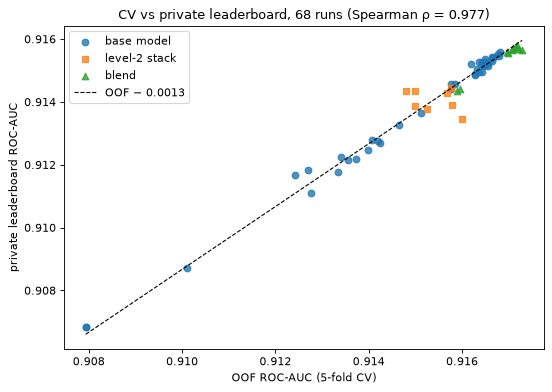

2 runs with OOF below 0.905 are outside the plotted range.


In [4]:
scored = runs.dropna(subset=['lb_private'])
rho = spearmanr(scored['oof_roc_auc'], scored['lb_private']).statistic
offset = (scored['oof_roc_auc'] - scored['lb_private'])
print(f'runs scored: {len(scored)}')
print(f'Spearman(OOF, private) = {rho:.3f}')
print(f'OOF - private offset: median {offset.median():+.5f}, '
      f'IQR {offset.quantile(0.25):+.5f} to {offset.quantile(0.75):+.5f}')

zoom = scored[scored['oof_roc_auc'] > 0.905]
fig, ax = plt.subplots(figsize=(7, 5))
for k, marker in [('base model', 'o'), ('level-2 stack', 's'), ('blend', '^')]:
    d = zoom[zoom['kind'] == k]
    ax.scatter(d['oof_roc_auc'], d['lb_private'], marker=marker, s=36, alpha=0.8, label=k)
lo, hi = zoom['oof_roc_auc'].min(), zoom['oof_roc_auc'].max()
ax.plot([lo, hi], [lo - offset.median(), hi - offset.median()], 'k--', lw=1,
        label=f'OOF − {offset.median():.4f}')
ax.set_xlabel('OOF ROC-AUC (5-fold CV)')
ax.set_ylabel('private leaderboard ROC-AUC')
ax.set_title(f'CV vs private leaderboard, {len(scored)} runs (Spearman ρ = {rho:.3f})')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'oof_vs_private.png', dpi=120)
plt.show()
print(f'{len(scored) - len(zoom)} runs with OOF below 0.905 are outside the plotted range.')

Cross-validation predicted the private leaderboard well: a rank correlation of 0.977
and a nearly constant offset (OOF higher by 0.0013, interquartile range
0.0012–0.0014). The offset itself is harmless; it is the stable ranking that matters,
and it is what made it safe to take decisions on OOF scores at all.

The exceptions are informative. The points furthest from the line are the
**level-2 stacks** — GBDTs trained on other models' OOF predictions. Several scored
well out-of-fold and poorly on the leaderboard, because their input features have a
different distribution on test rows than on training rows
([docs/stacking_experiments.md](docs/stacking_experiments.md)). The two runs outside
the plotted range are extreme versions of the same failure.

## 4. Error analysis: whom does everyone get wrong?

The consensus score for each customer is the average **rank** of their OOF
prediction across the curated pool of 11 diverse models (one per engine; see
`03_Blending.ipynb`). Two groups stand out:

* **missed churners** — customers who churned but sit in the bottom 30% of
  consensus risk; and
* **caught churners** — churners in the top 30%, for contrast.

Where the models agree this strongly, the error is not one model's quirk; it is
what the features cannot distinguish.

In [5]:
from src import blending as bl
from src.data import prepare_data

y, folds = bl.load_target_and_folds()
oof, _, meta, _ = bl.load_aligned_runs(y, exclude_versions=('blend_v1', 'fe_v5_stack', 'fe_v6_perfold'))
curated = bl.curate_pool(meta)
consensus = oof[curated].rank(pct=True).mean(axis=1).rank(pct=True).to_numpy()

train, _ = prepare_data(encoding='native')
df = train.assign(consensus=consensus)
df['group'] = np.select(
    [(df['Churn'] == 1) & (df['consensus'] < 0.3), (df['Churn'] == 1) & (df['consensus'] >= 0.7)],
    ['missed churners', 'caught churners'], default='other')

n_churn = int(df['Churn'].sum())
n_missed = int((df['group'] == 'missed churners').sum())
print(f'churners: {n_churn:,};  missed (bottom 30% of consensus risk): '
      f'{n_missed:,} = {n_missed / n_churn:.1%} of churners')
agree = (oof[curated].rank(pct=True) < 0.3).loc[df['group'] == 'missed churners'].mean(axis=1)
print(f'among missed churners, share of the 11 models that also rank them in their own '
      f'bottom 30%: median {agree.median():.0%}')

Loaded from cache (native): train_df (594194, 21), test_df (254655, 20)


Loaded from cache (native): train_df (594194, 21), test_df (254655, 20)
churners: 133,817;  missed (bottom 30% of consensus risk): 623 = 0.5% of churners


among missed churners, share of the 11 models that also rank them in their own bottom 30%: median 100%


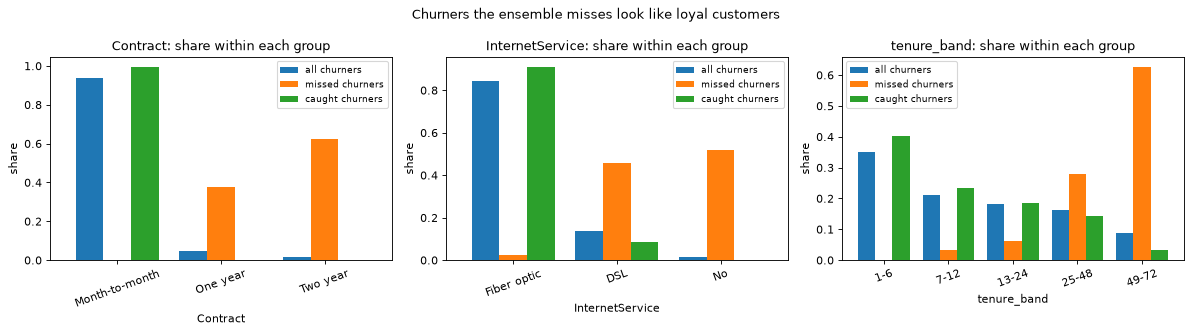

,tenure,MonthlyCharges,TotalCharges
group,,,
caught churners,9.0,85.5,734.0
missed churners,59.0,25.6,"1,728.2"
all churners,10.0,85.0,829.5


In [6]:
def profile(col, groups=('missed churners', 'caught churners')):
    base = df.loc[df['Churn'] == 1, col].value_counts(normalize=True).rename('all churners')
    parts = [df.loc[df['group'] == g, col].value_counts(normalize=True).rename(g) for g in groups]
    return pd.concat([base, *parts], axis=1).fillna(0)

df['tenure_band'] = pd.cut(df['tenure'], [0, 6, 12, 24, 48, 72],
                           labels=['1-6', '7-12', '13-24', '25-48', '49-72'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ['Contract', 'InternetService', 'tenure_band']):
    profile(col).plot.bar(ax=ax, rot=20, width=0.8)
    ax.set_title(f'{col}: share within each group')
    ax.set_ylabel('share')
    ax.legend(fontsize=8)
fig.suptitle('Churners the ensemble misses look like loyal customers')
fig.tight_layout()
fig.savefig(FIG_DIR / 'error_analysis.png', dpi=120)
plt.show()

numeric = (df[df['group'] != 'other'].groupby('group')[['tenure', 'MonthlyCharges', 'TotalCharges']]
           .median())
numeric.loc['all churners'] = df.loc[df['Churn'] == 1, ['tenure', 'MonthlyCharges', 'TotalCharges']].median()
numeric.style.format('{:,.1f}')

The confidently missed churners are few — 623 of 133,817 churners (0.5%) — and
every model agrees about them: the median missed churner is in the bottom 30% of
risk for all 11 models. They look like the company's most loyal customers: mostly on
one- or two-year contracts, with DSL or no internet service, a median tenure of 59
months and a median monthly bill of 25.60, against 10 months and 85.00 for churners
in general. Among all ~178,000 customers in that bottom-30% risk band only about
0.35% churn, so these churners cannot be separated from their loyal look-alikes
with the information in the 19 features.

This is the practical meaning of the ~0.917 plateau this project reached: the
remaining errors are customers whose recorded attributes carry no warning sign. Top
teams went further mainly by adding information from outside these features (see
[docs/top_solutions_analysis.md](docs/top_solutions_analysis.md)).